In [217]:
import os
import random
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.transforms import InterpolationMode
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ✅ Détection CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# ✅ Chemins locaux — adapte selon où tu mets tes datasets
BASE_DIR = r"C:\Users\emile\Poly\H26\INF8225\projet\Projet_INF8225"
DATASETS_DIR = os.path.join(BASE_DIR, "datasets")

ISIC_DIR  = os.path.join(DATASETS_DIR, "isic")
PETS_DIR  = os.path.join(DATASETS_DIR, "pets")
CRACK_DIR = os.path.join(DATASETS_DIR, "crack")

# ✅ Vérification
for name, path in [("isic", ISIC_DIR), ("pets", PETS_DIR), ("crack", CRACK_DIR)]:
    train_ok = os.path.exists(os.path.join(path, "train"))
    test_ok  = os.path.exists(os.path.join(path, "test"))


#Lien des datasets
#isic :  https://drive.google.com/drive/folders/12C3NGXHc-IeUkqeUGTCgweLiPeXsbeJ4?usp=drive_link
#pets :  https://drive.google.com/drive/folders/1HeZ1gOUrNPCYfOQMr72PIPAQ4PJBqPF2?usp=drive_link
#deepglobe : https://drive.google.com/drive/folders/1655iV3RwGmN0ftzRC6QjQG4eLXdTHO-A?usp=drive_link
#crack : https://drive.google.com/drive/folders/1nvZqrrwwzV0O_-EwofQgSB7qo2GCguBg?usp=drive_link

Device: cuda
Device: cuda
GPU: NVIDIA GeForce RTX 3070


In [218]:
########################################
# SEED GLOBAL — REPRODUCTIBILITÉ
########################################

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

########################################
# CONFIGURATION
########################################

# dataset à utiliser : "isic" | "pets" | "deepglobe" | "crack"
DATASET = "isic"

# augmentation : "baseline" | "flip" | "flip_rotation" | "full_aug" | "geo_strong" | "extreme_aug"
AUGMENTATION_CONFIG = "geo_strong"

# isic : 0.2 | pets : 0.17 | crack : 0.14
# fraction du train set à utiliser (float 0-1 ou int)
TRAIN_SIZE = 0.2

# early stopping
PATIENCE = 30

In [219]:
class ISICDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None, augmentation_config="baseline"):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.augmentation_config = augmentation_config

        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))
        assert len(self.images) == len(self.masks), "Images et masques doivent correspondre !"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # Resize de base
        image = transforms.Resize((256, 256))(image)
        mask = transforms.Resize((256, 256), interpolation=InterpolationMode.NEAREST)(mask)

        aug = self.augmentation_config

        # AUGMENTATIONS SYNCHRONISÉES
        if aug in ["flip", "flip_rotation", "full_aug", "geo_strong", "extreme_aug"]:
            if random.random() < 0.5:
                image = transforms.functional.hflip(image)
                mask = transforms.functional.hflip(mask)

        if aug in ["full_aug", "geo_strong", "extreme_aug"]:
            if random.random() < 0.5:
                image = transforms.functional.vflip(image)
                mask = transforms.functional.vflip(mask)

        if aug in ["flip_rotation", "full_aug", "geo_strong", "extreme_aug"]:
            angle = random.uniform(-25, 25)
            image = transforms.functional.rotate(image, angle)
            mask = transforms.functional.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

        if aug in ["geo_strong", "extreme_aug"]:
            tx = random.uniform(-0.1, 0.1) * 256
            ty = random.uniform(-0.1, 0.1) * 256
            scale = random.uniform(0.8, 1.2)
            shear = random.uniform(-10, 10)
            image = transforms.functional.affine(image, angle=0, translate=(tx, ty), scale=scale, shear=shear)
            mask = transforms.functional.affine(mask, angle=0, translate=(tx, ty), scale=scale, shear=shear,
                                                interpolation=InterpolationMode.NEAREST)
            
        # IMAGE ONLY
        if aug in ["full_aug", "extreme_aug"]:
            image = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)(image)

        if aug == "extreme_aug":
            image = transforms.GaussianBlur(kernel_size=3)(image)

        # TENSORS
        image = transforms.ToTensor()(image)
        image = transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])(image)
        mask = transforms.ToTensor()(mask)
        mask = (mask > 0).float()

        return image, mask    


class OxfordPetDataset(Dataset):
    """
    CORRECTION : les augmentations utilisent maintenant image_transform / mask_transform
    passés en paramètre, comme les deux autres datasets. Plus de dépendance à la
    variable globale AUGMENTATION_CONFIG.
    """
    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None, augmentation_config="baseline"):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.augmentation_config = augmentation_config

        self.images = []
        self.masks = []

        for img in sorted(os.listdir(images_dir)):
            mask_name = img.replace(".jpg", ".png")
            mask_path = os.path.join(masks_dir, mask_name)
            if os.path.exists(mask_path):
                self.images.append(img)
                self.masks.append(mask_name)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        # Binarisation
        mask_np = np.array(mask)
        mask_np = (mask_np == 1).astype(np.uint8) * 255
        mask = Image.fromarray(mask_np)

        # Resize de base
        image = transforms.Resize((256, 256))(image)
        mask = transforms.Resize((256, 256), interpolation=InterpolationMode.NEAREST)(mask)

        aug = self.augmentation_config

        ########################################
        # AUGMENTATIONS SYNCHRONISÉES
        ########################################

        if aug in ["flip", "flip_rotation", "full_aug", "geo_strong", "extreme_aug"]:
            if random.random() < 0.5:
                image = transforms.functional.hflip(image)
                mask = transforms.functional.hflip(mask)

        if aug in ["full_aug", "geo_strong", "extreme_aug"]:
            if random.random() < 0.5:
                image = transforms.functional.vflip(image)
                mask = transforms.functional.vflip(mask)

        if aug in ["flip_rotation", "full_aug", "geo_strong", "extreme_aug"]:
            angle = random.uniform(-25, 25)
            image = transforms.functional.rotate(image, angle)
            mask = transforms.functional.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

        if aug in ["geo_strong", "extreme_aug"]:
            tx = random.uniform(-0.1, 0.1) * 256
            ty = random.uniform(-0.1, 0.1) * 256
            scale = random.uniform(0.8, 1.2)
            shear = random.uniform(-10, 10)

            image = transforms.functional.affine(image, angle=0, translate=(tx, ty), scale=scale, shear=shear)
            mask = transforms.functional.affine(mask, angle=0, translate=(tx, ty), scale=scale, shear=shear,
                                                interpolation=InterpolationMode.NEAREST)

        ########################################
        # IMAGE ONLY AUGMENTATIONS
        ########################################

        if aug in ["full_aug", "extreme_aug"]:
            image = transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)(image)

        if aug == "extreme_aug":
            image = transforms.GaussianBlur(kernel_size=3)(image)

        ########################################
        # TENSORS
        ########################################

        image = transforms.ToTensor()(image)
        image = transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])(image)

        mask = transforms.ToTensor()(mask)
        mask = (mask > 0.5).float()

        return image, mask


class CrackDataset(Dataset):
    def __init__(self, images_dir, masks_dir, image_transform=None, mask_transform=None, augmentation_config="baseline"):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.image_transform = image_transform
        self.mask_transform = mask_transform
        self.augmentation_config = augmentation_config

        self.images = sorted(os.listdir(images_dir))
        self.masks = sorted(os.listdir(masks_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # ← niveaux de gris, pas RGB

        seed = random.randint(0, 2**32 - 1)

        if self.image_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            image = self.image_transform(image)

        if self.mask_transform:
            random.seed(seed)
            torch.manual_seed(seed)
            mask = self.mask_transform(mask)  # shape: [1, H, W], valeurs [0, 1]

        mask = (mask > 0.5).float()  # ← binarisation simple, plus de logique RGB

        return image, mask

In [220]:
########################################
# TRANSFORMS
########################################
import torch
from torchvision import transforms
from torchvision.transforms import InterpolationMode

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def build_image_transform(augmentation_config):
    if augmentation_config == "baseline":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
        ])

    elif augmentation_config == "flip":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
        ])

    elif augmentation_config == "flip_rotation":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(20),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
        ])

    elif augmentation_config == "full_aug":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(25),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
        ])

    elif augmentation_config == "geo_strong":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(30),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
        ])

    elif augmentation_config == "extreme_aug":
        return transforms.Compose([
            transforms.Resize((256, 256)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(35),
            transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.7, 1.3), shear=15),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
            transforms.GaussianBlur(kernel_size=3),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
        ])

    else:
        raise ValueError(f"Unknown augmentation config: {augmentation_config}")


base_image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

base_mask_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=InterpolationMode.NEAREST),
    transforms.ToTensor()
])

image_transform = build_image_transform(AUGMENTATION_CONFIG)
mask_transform = base_mask_transform  # le mask ne reçoit pas de ColorJitter etc.

print("Using augmentation:", AUGMENTATION_CONFIG)

Using augmentation: geo_strong


In [221]:
########################################
# DATASET SELECTION
########################################

DATASET_CLASSES = {
    "isic": ISICDataset,
    "pets": OxfordPetDataset,
    "crack": CrackDataset,
    #"deepglobe": DeepGlobeDataset,
}

DATASET_PATHS = {
    "isic": {
        "train_images": os.path.join(BASE_DIR, "datasets", "isic", "train", "images"),
        "train_masks":  os.path.join(BASE_DIR, "datasets", "isic", "train", "masks"),
        "test_images":  os.path.join(BASE_DIR, "datasets", "isic", "test", "images"),
        "test_masks":   os.path.join(BASE_DIR, "datasets", "isic", "test", "masks"),
    },
    "pets": {
        "train_images": os.path.join(BASE_DIR, "datasets", "pets", "train", "images"),
        "train_masks":  os.path.join(BASE_DIR, "datasets", "pets", "train", "masks"),
        "test_images":  os.path.join(BASE_DIR, "datasets", "pets", "test", "images"),
        "test_masks":   os.path.join(BASE_DIR, "datasets", "pets", "test", "masks"),
    },
    "deepglobe": {
        "train_images": os.path.join(BASE_DIR, "datasets", "deepglobe", "train", "images"),
        "train_masks":  os.path.join(BASE_DIR, "datasets", "deepglobe", "train", "masks"),
        "test_images":  os.path.join(BASE_DIR, "datasets", "deepglobe", "test", "images"),
        "test_masks":   os.path.join(BASE_DIR, "datasets", "deepglobe", "test", "masks"),
    },
    "crack": {
        "train_images": os.path.join(BASE_DIR, "datasets", "crack", "train", "images"),
        "train_masks":  os.path.join(BASE_DIR, "datasets", "crack", "train", "masks"),
        "test_images":  os.path.join(BASE_DIR, "datasets", "crack", "test", "images"),
        "test_masks":   os.path.join(BASE_DIR, "datasets", "crack", "test", "masks"),
    },
}
if DATASET not in DATASET_CLASSES:
    raise ValueError(f"Unknown dataset: {DATASET}")

DatasetClass = DATASET_CLASSES[DATASET]
paths = DATASET_PATHS[DATASET]

print("Dataset:", DATASET)

Dataset: isic


In [222]:
from torch.utils.data import Subset, random_split

########################################
# DATASETS DE BASE (NE PAS MELANGER)
########################################

train_full = DatasetClass(
    paths["train_images"],
    paths["train_masks"],
    image_transform=image_transform,
    mask_transform=mask_transform,
    augmentation_config=AUGMENTATION_CONFIG,
)

test_dataset = DatasetClass(
    paths["test_images"],
    paths["test_masks"],
    image_transform=base_image_transform,
    mask_transform=base_mask_transform,
    augmentation_config="baseline",
)

########################################
# SOUS-ECHANTILLONNAGE TRAIN (FEW-SHOT)
########################################

total_train = len(train_full)

if isinstance(TRAIN_SIZE, float):
    train_subset_size = int(TRAIN_SIZE * total_train)
else:
    train_subset_size = min(TRAIN_SIZE, total_train)

train_subset = Subset(train_full, range(train_subset_size))

########################################
# SPLIT TRAIN / VAL
########################################

train_size = int(0.85 * len(train_subset))
val_size = len(train_subset) - train_size

train_dataset, val_dataset = random_split(
    train_subset,
    [train_size, val_size]
)


print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 107 | Val: 19 | Test: 270


In [223]:
########################################
# MODEL
########################################

MODEL_NAME = "deeplabv3plus"

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UpConv(nn.Module):
    """
    in_channels = canaux du tenseur upsamplé + canaux du skip connection
    out_channels = canaux de sortie après DoubleConv
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.size() != skip.size():
            x = F.interpolate(x, size=skip.shape[2:])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        f = features
        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.enc1 = DoubleConv(in_channels, f[0])
        self.enc2 = DoubleConv(f[0], f[1])
        self.enc3 = DoubleConv(f[1], f[2])
        self.enc4 = DoubleConv(f[2], f[3])

        # Bottleneck
        self.bottleneck = nn.Sequential(
            DoubleConv(f[3], f[3] * 2),
            nn.Dropout2d(0.3),
        )

        # Decoder
        # in_channels = bottleneck_out + enc4_out = f[3]*2 + f[3]
        self.up4 = UpConv(f[3] * 2 + f[3], f[3])
        self.up3 = UpConv(f[3] + f[2], f[2])
        self.up2 = UpConv(f[2] + f[1], f[1])
        self.up1 = UpConv(f[1] + f[0], f[0])

        self.final = nn.Conv2d(f[0], out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b, e4)
        d3 = self.up3(d4, e3)
        d2 = self.up2(d3, e2)
        d1 = self.up1(d2, e1)

        return self.final(d1)

########################################
# DEEPLABV3+ 
########################################

import torchvision.models as tvm

class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels=256):
        super().__init__()
        # 1x1 conv
        self.c0 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
        # Dilatées : taux 6, 12, 18
        self.c1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=6,  dilation=6,  bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
        self.c2 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=12, dilation=12, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
        self.c3 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=18, dilation=18, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
        # Global average pooling
        self.gap = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
        # Projection finale
        self.proj = nn.Sequential(
            nn.Conv2d(out_channels * 5, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True),
            nn.Dropout2d(0.3)
        )

    def forward(self, x):
        size = x.shape[2:]
        gap  = F.interpolate(self.gap(x), size=size, mode="bilinear", align_corners=True)
        x = torch.cat([self.c0(x), self.c1(x), self.c2(x), self.c3(x), gap], dim=1)
        return self.proj(x)


class DeepLabV3Plus(nn.Module):
    def __init__(self, out_channels=1, pretrained=False):
        super().__init__()

        # Backbone ResNet50 pré-entraîné
        weights = tvm.ResNet50_Weights.DEFAULT if pretrained else None
        backbone = tvm.resnet50(weights=weights)

        # Layer1 → low-level features (256 ch, stride 4)
        self.layer0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1   # 256 ch
        self.layer2 = backbone.layer2   # 512 ch
        self.layer3 = backbone.layer3   # 1024 ch
        self.layer4 = backbone.layer4   # 2048 ch

        # ASPP sur les features profondes
        self.aspp = ASPP(2048, 256)

        # Projection low-level features
        self.low_proj = nn.Sequential(
            nn.Conv2d(256, 48, 1, bias=False),
            nn.BatchNorm2d(48), nn.ReLU(inplace=True)
        )

        # Décodeur
        self.decoder = nn.Sequential(
            nn.Conv2d(256 + 48, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, out_channels, 1)
        )

    def forward(self, x):
        size = x.shape[2:]

        x      = self.layer0(x)
        low    = self.layer1(x)   # low-level features
        x      = self.layer2(low)
        x      = self.layer3(x)
        x      = self.layer4(x)

        x      = self.aspp(x)
        x      = F.interpolate(x, size=low.shape[2:], mode="bilinear", align_corners=True)

        low    = self.low_proj(low)
        x      = torch.cat([x, low], dim=1)
        x      = self.decoder(x)

        return F.interpolate(x, size=size, mode="bilinear", align_corners=True)


# ── Utilisation ──


if MODEL_NAME == "unet":
    model = UNet().to(device)
elif MODEL_NAME == "deeplabv3plus":
    model = DeepLabV3Plus().to(device)
elif MODEL_NAME == "deeplabv3plus_trained":
    model = DeepLabV3Plus(pretrained=True).to(device)

mocel = model.float()

In [224]:
########################################
# LOSS & OPTIMIZER
########################################

def dice_loss(pred, mask, smooth=1e-6):
    pred = torch.sigmoid(pred)
    intersection = (pred * mask).sum(dim=(1, 2, 3))
    dice = (2 * intersection + smooth) / (pred.sum(dim=(1, 2, 3)) + mask.sum(dim=(1, 2, 3)) + smooth)
    return 1 - dice.mean()

def combined_loss(pred, mask):
    return nn.BCEWithLogitsLoss()(pred, mask) + dice_loss(pred, mask)

criterion = combined_loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode="max",factor=0.5,patience=3)

In [225]:
########################################
# METRICS — opèrent sur logits bruts
########################################

def binarize(pred):
    """Applique sigmoid + seuil 0.5 sur des logits."""
    return (torch.sigmoid(pred) > 0.5).float()

def iou_score(pred, mask):
    pred = binarize(pred)
    intersection = (pred * mask).sum()
    union = pred.sum() + mask.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)

def pixel_accuracy(pred, mask):
    pred = binarize(pred)
    return (pred == mask).float().mean()

def dice_score(pred, mask):
    pred = binarize(pred)
    intersection = (pred * mask).sum()
    return (2 * intersection + 1e-6) / (pred.sum() + mask.sum() + 1e-6)

def precision_score(pred, mask):
    pred = binarize(pred)
    tp = (pred * mask).sum()
    fp = (pred * (1 - mask)).sum()
    return (tp + 1e-6) / (tp + fp + 1e-6)

def recall_score(pred, mask):
    pred = binarize(pred)
    tp = (pred * mask).sum()
    fn = ((1 - pred) * mask).sum()
    return (tp + 1e-6) / (tp + fn + 1e-6)

In [226]:
########################################
# DATALOADERS
########################################

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    drop_last=False
)

print("Dataloaders ready")

Dataloaders ready


In [227]:
########################################
# NORMALISATION ImageNet (obligatoire avec transfer learning)
########################################

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def build_image_transform(augmentation_config):
    base = [transforms.Resize((256, 256))]
    augs = []

    if augmentation_config in ["flip", "flip_rotation", "full_aug", "geo_strong", "extreme_aug"]:
        augs.append(transforms.RandomHorizontalFlip())
    if augmentation_config in ["full_aug", "geo_strong", "extreme_aug"]:
        augs.append(transforms.RandomVerticalFlip())
    if augmentation_config in ["flip_rotation", "full_aug", "geo_strong", "extreme_aug"]:
        augs.append(transforms.RandomRotation(25))
    if augmentation_config in ["geo_strong", "extreme_aug"]:
        augs.append(transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2), shear=10))
    if augmentation_config in ["full_aug", "extreme_aug"]:
        augs.append(transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2))
    if augmentation_config == "extreme_aug":
        augs.append(transforms.GaussianBlur(kernel_size=3))

    return transforms.Compose(base + augs + [
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)  # <-- ImageNet au lieu de [0.5]
    ])

base_image_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [ ]:
########################################
# GRAD SCALER — CPU-safe
########################################

use_amp = device.type == "cuda"
scaler = torch.amp.GradScaler("cuda") if use_amp else None

def autocast_ctx():
    if use_amp:
        return torch.amp.autocast("cuda")
    import contextlib
    return contextlib.nullcontext()

########################################
# TRAINING LOOP
########################################

epochs = 20
best_iou = 0
patience_counter = 0

train_losses, val_losses = [], []
iou_scores_hist, dice_scores_hist, acc_scores_hist = [], [], []

for epoch in range(epochs):

    # ── TRAIN ──
    model.train()
    train_loss = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1} train"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        with autocast_ctx():
            preds = model(images)
            loss = criterion(preds, masks)

        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── VALIDATION ──
    model.eval()
    val_loss = iou = acc = dice = 0.0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)

            with autocast_ctx():
                preds = model(images)
                loss = criterion(preds, masks)

            val_loss += loss.item()
            iou  += iou_score(preds, masks).item()
            acc  += pixel_accuracy(preds, masks).item()
            dice += dice_score(preds, masks).item()

    val_loss /= len(val_loader)
    iou  /= len(val_loader)
    acc  /= len(val_loader)
    dice /= len(val_loader)

    # LR scheduler
    scheduler.step(iou)

    # Stockage
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    iou_scores_hist.append(iou)
    dice_scores_hist.append(dice)
    acc_scores_hist.append(acc)

    # Save best
    if iou > best_iou:
        best_iou = iou
        patience_counter = 0
        torch.save(model.state_dict(), "best_unet.pth")
    else:
        patience_counter += 1

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"  Train loss : {train_loss:.4f}")
    print(f"  Val   loss : {val_loss:.4f}")
    print(f"  IoU        : {iou:.4f}   (best={best_iou:.4f})")
    print(f"  Pixel acc  : {acc:.4f}")
    print(f"  Dice       : {dice:.4f}")
    print(f"  LR         : {optimizer.param_groups[0]['lr']:.2e}")
    print(f"  Patience   : {patience_counter}/{PATIENCE}")

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping après {epoch+1} epochs (patience={PATIENCE}).")
        break

torch.save(model.state_dict(), f"unet_{DATASET}_final.pth")
print("Modèle final sauvegardé.")

Epoch 1 train: 100%|██████████| 13/13 [00:02<00:00,  4.62it/s]



Epoch 1/20
  Train loss : 1.0256
  Val   loss : 2.8998
  IoU        : 0.2652   (best=0.2652)
  Pixel acc  : 0.2885
  Dice       : 0.4135
  LR         : 1.00e-03
  Patience   : 0/30


Epoch 2 train: 100%|██████████| 13/13 [00:02<00:00,  4.56it/s]



Epoch 2/20
  Train loss : 0.5534
  Val   loss : 0.6434
  IoU        : 0.6219   (best=0.6219)
  Pixel acc  : 0.8816
  Dice       : 0.7654
  LR         : 1.00e-03
  Patience   : 0/30


Epoch 3 train:  85%|████████▍ | 11/13 [00:02<00:00,  4.36it/s]

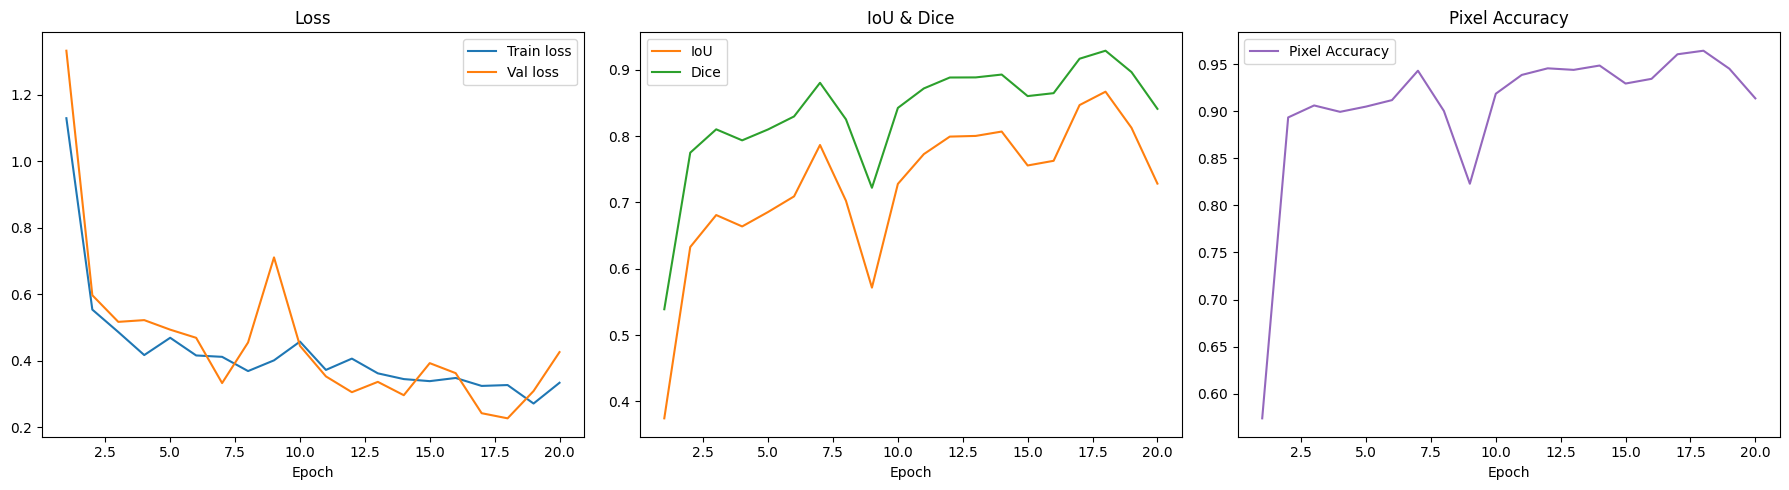

Courbes sauvegardées : training_curves.png


In [ ]:
########################################
# COURBES D'ENTRAÎNEMENT
########################################

epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, train_losses, label="Train loss")
axes[0].plot(epochs_range, val_losses, label="Val loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, iou_scores_hist, label="IoU", color="tab:orange")
axes[1].plot(epochs_range, dice_scores_hist, label="Dice", color="tab:green")
axes[1].set_title("IoU & Dice")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(epochs_range, acc_scores_hist, label="Pixel Accuracy", color="tab:purple")
axes[2].set_title("Pixel Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Courbes sauvegardées : training_curves.png")

In [ ]:
########################################
# ÉVALUATION COMPLÈTE SUR LE TEST SET
########################################

# Charger le meilleur modèle
model.load_state_dict(torch.load("best_unet.pth", map_location=device))
model.eval()

test_iou = test_dice = test_acc = test_prec = test_rec = 0.0

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Test evaluation"):
        images, masks = images.to(device), masks.to(device)
        with autocast_ctx():
            preds = model(images)

        test_iou  += iou_score(preds, masks).item()
        test_dice += dice_score(preds, masks).item()
        test_acc  += pixel_accuracy(preds, masks).item()
        test_prec += precision_score(preds, masks).item()
        test_rec  += recall_score(preds, masks).item()

n = len(test_loader)
print("\n===== TEST SET RESULTS =====")
print(f"  IoU       : {test_iou/n:.4f}")
print(f"  Dice      : {test_dice/n:.4f}")
print(f"  Pixel Acc : {test_acc/n:.4f}")
print(f"  Precision : {test_prec/n:.4f}")
print(f"  Recall    : {test_rec/n:.4f}")

C:\Users\emile\AppData\Local\Temp\ipykernel_36784\534965584.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_unet.pth", map_locatio


===== TEST SET RESULTS =====
  IoU       : 0.6320
  Dice      : 0.7622
  Pixel Acc : 0.8930
  Precision : 0.8721
  Recall    : 0.7290


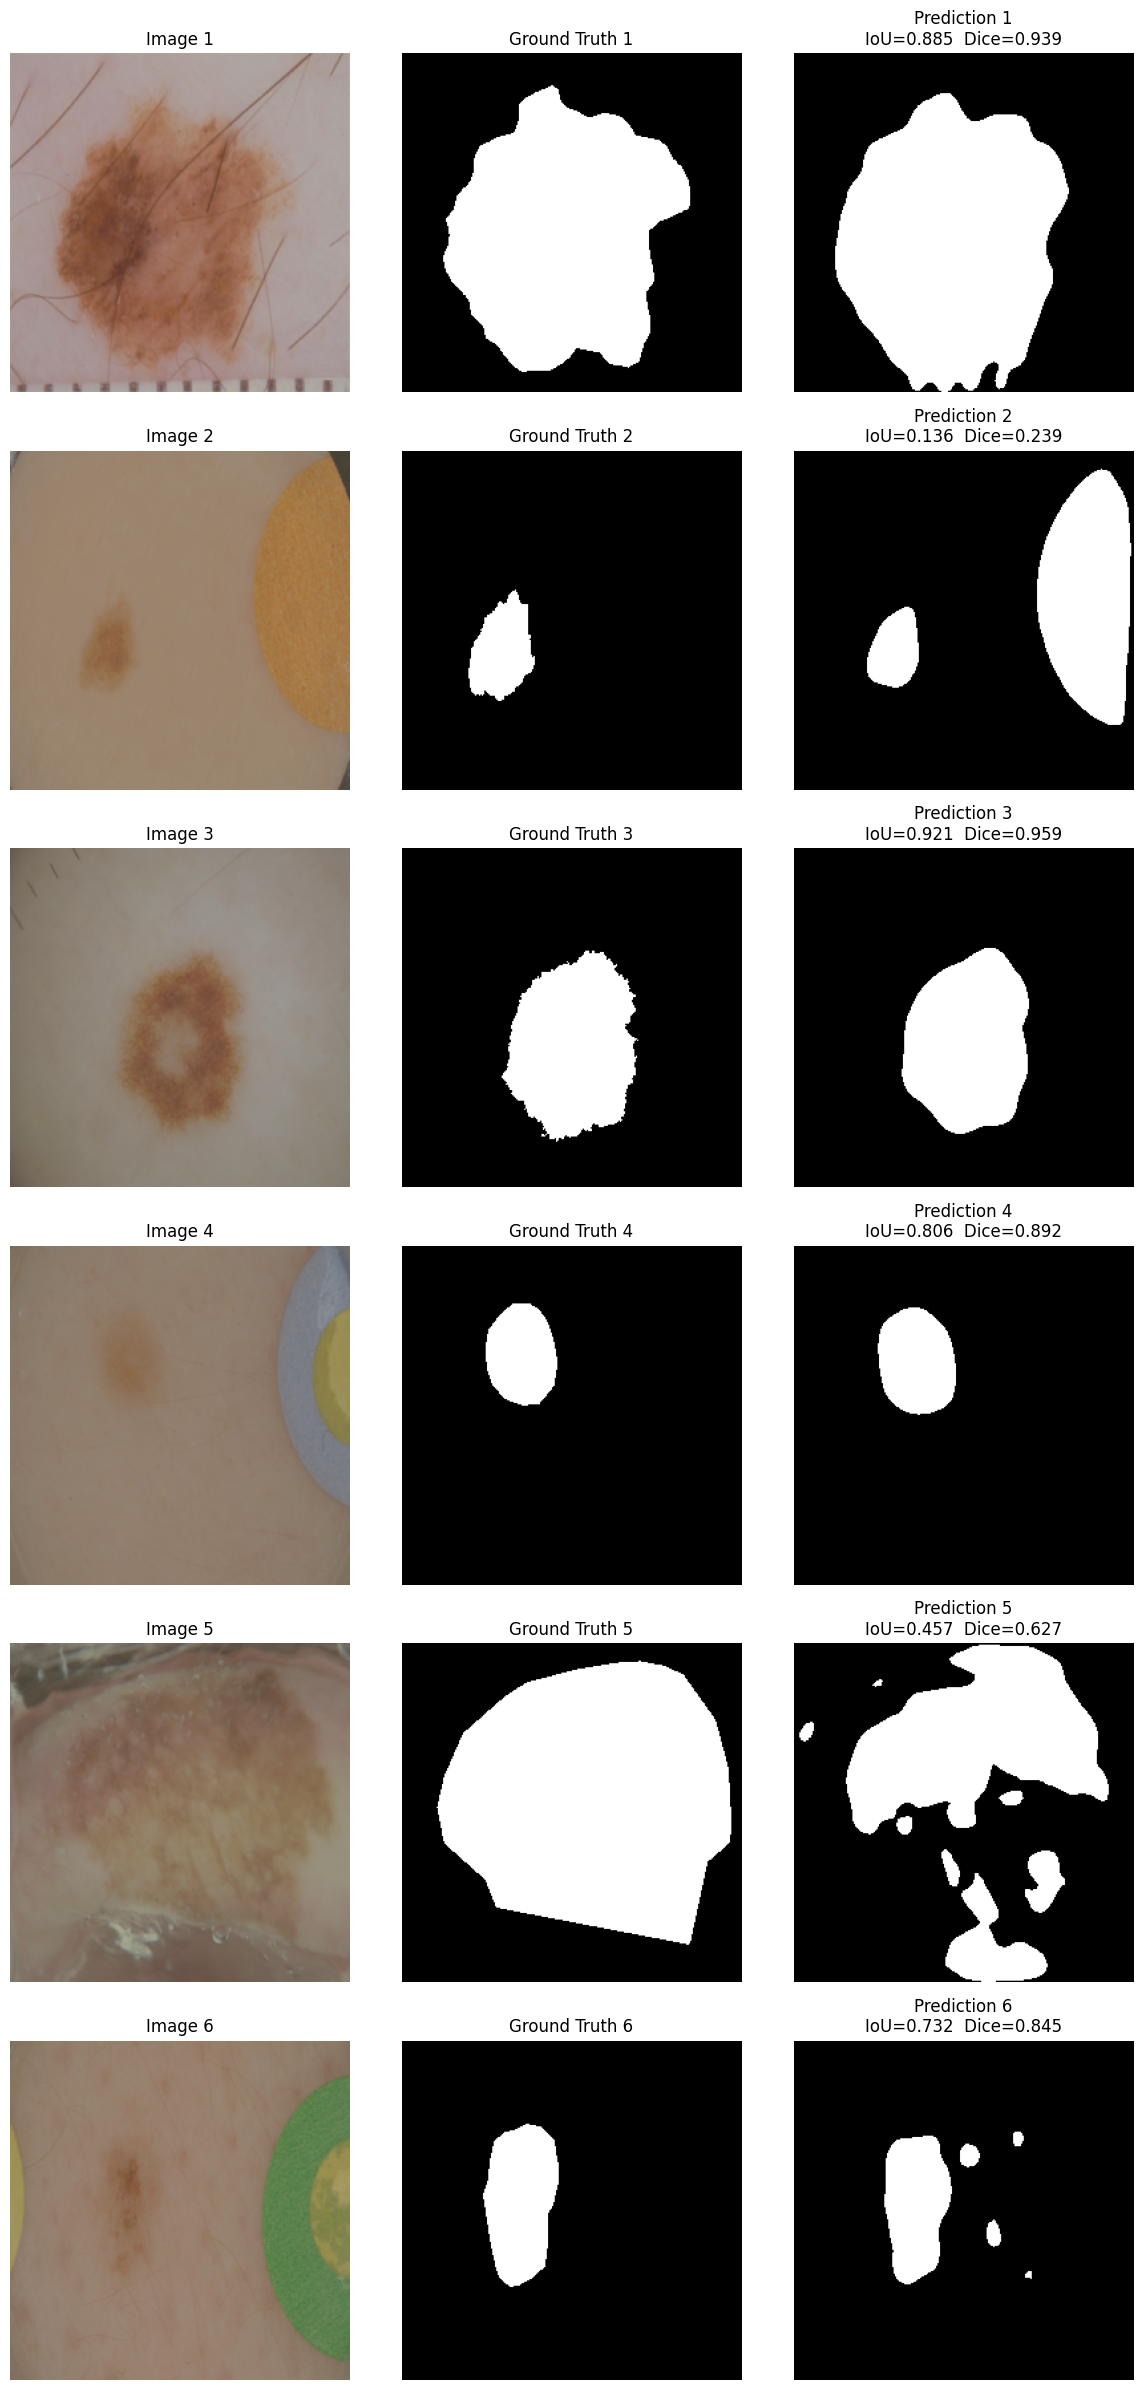

Prédictions sauvegardées : predictions.png


In [ ]:
########################################
# VISUALISATION QUALITATIVE (6 exemples)
########################################

def denormalize(tensor, mean=IMAGENET_MEAN , std=IMAGENET_STD  ):
    t = tensor.clone()
    for c, m, s in zip(t, mean, std):
        c.mul_(s).add_(m)
    return t.clamp(0, 1)

num_samples = 6
indices = np.random.choice(len(test_dataset), num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))

for i, idx in enumerate(indices):

    image, mask = test_dataset[idx]
    image_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(image_tensor)

    pred_bin = binarize(pred).squeeze().cpu()
    image_display = denormalize(image).permute(1, 2, 0).cpu()

    iou_val  = iou_score(pred.cpu(), mask.unsqueeze(0)).item()
    dice_val = dice_score(pred.cpu(), mask.unsqueeze(0)).item()

    axes[i, 0].imshow(image_display)
    axes[i, 0].set_title(f"Image {i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask.squeeze(), cmap="gray")
    axes[i, 1].set_title(f"Ground Truth {i+1}")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(pred_bin, cmap="gray")
    axes[i, 2].set_title(f"Prediction {i+1}\nIoU={iou_val:.3f}  Dice={dice_val:.3f}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()

print("Prédictions sauvegardées : predictions.png")
